In [1]:
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
data = pd.read_csv("Pokemon.csv")
data.head(50)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

| Columna | Tipo | Descripción |
|---------|------|-------------|
| **#** | `int` | Índice único del Pokémon |
| **Name** | `str` | Nombre del Pokémon |
| **Type 1** | `str` (categórica) | Tipo principal ("elemento") |
| **Type 2** | `str` (categórica) | Tipo secundario (puede ser vacío) |
| **Total** | `int` | Suma de todas las estadísticas base |
| **HP** | `int` | Puntos de vida |
| **Attack** | `int` | Puntuación de ataque |
| **Defense** | `int` | Puntuación de defensa |
| **Sp. Atk** | `int` | Puntuación de ataque especial |
| **Sp. Def** | `int` | Puntuación de defensa especial |
| **Speed** | `int` | Velocidad del Pokémon |
| **Generation** | `int` | Generación (región/época: 1-8) |
| **Legendary** | `bool` | Si es Pokémon legendario (True/False) |

### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

### Datos a tomar para el  entrenamiento
Nuestra hipótesis es que un Pokémon es clasificado como legendario principalmente por sus estadísticas numéricas base. Por esta razón, utilizaremos las siguientes características para el entrenamiento
- HP
- ataque
- defensa
- sp atk
- sp def
- speed

### Exclusiones
Type 1 y Type 2: Se descartaron porque los Pokémon legendarios existen en todos los tipos (ej: Rayquaza es Dragon/Volador). El tipo no determina si es legendario.

Name y #: Son únicamente identificadores del Pokémon, sin relación con su clasificación legendaria.

Generation: La generación indica solo el período de lanzamiento, no si un Pokémon es legendario o no.

In [3]:
# 1. Seleccionar features (características) y target (variable objetivo)
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = data[features]  # Features
y = data['Legendary']  # Target


In [4]:
print(X.isnull().sum())



HP         0
Attack     0
Defense    0
Sp. Atk    0
Sp. Def    0
Speed      0
dtype: int64


In [5]:
print(y.isnull().sum())

0


In [6]:
# Normalizacion de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [8]:
#Convertir a tensores de pytorch
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.values.astype(float))
y_test_tensor = torch.FloatTensor(y_test.values.astype(float))


In [9]:
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribución Legendary en train:\n{y_train.value_counts()}")
print(f"\nDistribución Legendary en test:\n{y_test.value_counts()}")

Train set: (640, 6)
Test set: (160, 6)

Distribución Legendary en train:
Legendary
False    585
True      55
Name: count, dtype: int64

Distribución Legendary en test:
Legendary
False    150
True      10
Name: count, dtype: int64


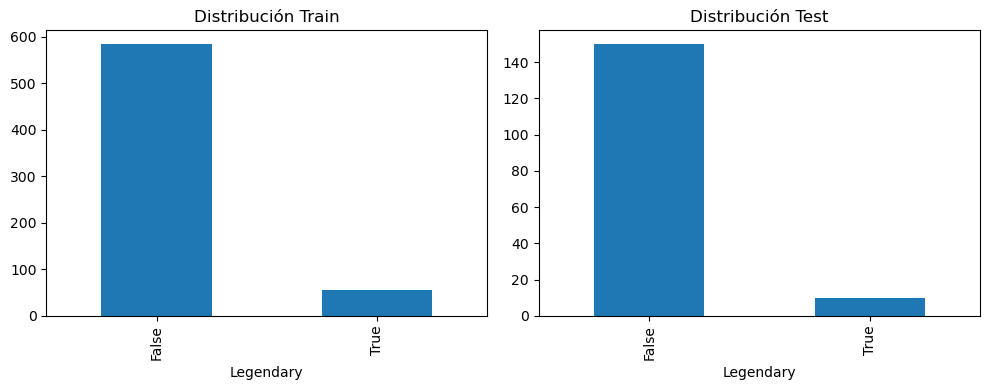

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], title='Distribución Train')
y_test.value_counts().plot(kind='bar', ax=axes[1], title='Distribución Test')

plt.tight_layout()
plt.show()

### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

In [ ]:
from models import MultiLayerPerceptronSig,MultiLayerPerceptronRelu, MultiLayerPerceptron2Cap
## se elige el valor input = 6 ya que hay 6 columnas utiles
modelo1 = MultiLayerPerceptronSig(input_dim=6, output_dim=2, hidden_dim=16)
modelo2 = MultiLayerPerceptron2Cap(input_dim=6, output_dim=2, hidden_dim=16) ## se eligen más nodos ocultos 
modelo3 = MultiLayerPerceptronRelu(input_dim=6, output_dim=2, hidden_dim=16) ## se prueba con funcion de activación relu
modelo1.hidden.weight, modelo1.hidden.bias, modelo1.output.weight, modelo1.output.bias

(Parameter containing:
 tensor([[-0.0256,  0.2788, -0.1644,  0.1634, -0.1590, -0.0328],
         [-0.0751, -0.3397, -0.1538,  0.3642,  0.1921,  0.3018],
         [ 0.0421,  0.3628,  0.3028, -0.3722, -0.3599, -0.2107],
         [ 0.2774, -0.3276, -0.4057,  0.0083,  0.1299,  0.0122],
         [-0.0324, -0.0248, -0.1278,  0.1736, -0.1161, -0.3808],
         [ 0.1470,  0.1435,  0.4017,  0.1359,  0.2949,  0.0462],
         [-0.1347,  0.1209, -0.0447, -0.3072, -0.1316,  0.2521],
         [-0.0554,  0.2593,  0.3595, -0.2076, -0.2641,  0.1634],
         [ 0.1034,  0.2448, -0.2540, -0.3213, -0.3006,  0.0981],
         [ 0.1637,  0.0095,  0.2924,  0.2201, -0.0772, -0.3784],
         [ 0.2908, -0.1468, -0.3258,  0.0067, -0.3462,  0.0376],
         [-0.3533,  0.2313,  0.1045, -0.3031,  0.2103, -0.1213],
         [-0.0597, -0.1802,  0.1848,  0.3803, -0.0892, -0.3574],
         [-0.2106, -0.3608,  0.1312, -0.1481,  0.0950,  0.2001],
         [ 0.2653,  0.1363, -0.3653,  0.3800,  0.0489,  0.1546],
  

In [13]:
modelo2.hidden.weight, modelo2.hidden.bias, modelo2.output.weight, modelo2.output.bias

(Parameter containing:
 tensor([[-0.3894,  0.1959, -0.1228,  0.1588, -0.0575,  0.1076],
         [ 0.3524, -0.3029,  0.3998, -0.0443, -0.0541, -0.0098],
         [-0.3099, -0.0970, -0.2499,  0.1067,  0.0555,  0.1200],
         [-0.2467, -0.2624,  0.3325,  0.3765,  0.0574,  0.0202],
         [ 0.1538, -0.0257, -0.1378, -0.0637,  0.3708,  0.1454],
         [-0.0111,  0.3506, -0.1329, -0.3963, -0.0155, -0.3261],
         [ 0.3980,  0.0292,  0.4013, -0.3967, -0.2851, -0.0371],
         [ 0.3983,  0.0088, -0.2083,  0.2019,  0.3034,  0.2336],
         [ 0.3185, -0.3182,  0.3056, -0.2980, -0.1549,  0.1429],
         [ 0.2103,  0.3229, -0.2422,  0.2997,  0.3677, -0.0938],
         [-0.1600,  0.0327,  0.3268, -0.0096,  0.0211,  0.2684],
         [ 0.3103,  0.2170, -0.0942,  0.3727, -0.3831,  0.3388],
         [-0.2407,  0.2617,  0.2584, -0.3467, -0.1645, -0.2497],
         [ 0.1273,  0.1240,  0.2796,  0.3363, -0.0508, -0.0068],
         [-0.4011, -0.1096, -0.3673, -0.0294, -0.1954, -0.1995],
  

In [15]:
modelo3.hidden.weight, modelo3.hidden.bias, modelo3.output.weight, modelo3.output.bias

(Parameter containing:
 tensor([[ 0.0233,  0.3417,  0.0713, -0.0676,  0.1754,  0.0429],
         [ 0.4001,  0.3851, -0.1781,  0.3567, -0.3348, -0.0206],
         [-0.2213, -0.1944, -0.1764, -0.0251,  0.0861, -0.3093],
         [ 0.1867,  0.3858, -0.2279,  0.2965,  0.2074, -0.1769],
         [-0.0998, -0.2883, -0.2681, -0.2490,  0.1359,  0.2151],
         [-0.2872, -0.2217,  0.2957, -0.1126, -0.3331,  0.3757],
         [ 0.2734,  0.0209, -0.0909,  0.0804, -0.3255,  0.2732],
         [ 0.2886,  0.3189, -0.0926,  0.0962,  0.0503,  0.4040],
         [-0.0006,  0.0985,  0.3326, -0.2338,  0.2299, -0.2879],
         [-0.0630, -0.3774,  0.3732,  0.2427, -0.0721,  0.3951],
         [ 0.1024, -0.0648,  0.0806,  0.1600,  0.1292, -0.3258],
         [ 0.1468,  0.0603, -0.2586,  0.1439, -0.1635, -0.1922],
         [-0.3639,  0.1133, -0.1028, -0.3265,  0.0966, -0.0682],
         [-0.1659, -0.0469, -0.2299,  0.1422,  0.3744, -0.1683],
         [-0.3449, -0.3817,  0.3110,  0.1514, -0.1930, -0.2755],
  

### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [ ]:
## Funcion de costo CrossEntropyLoss -> ya que esta sirve para problemas de clasificación
criterion = nn.CrossEntropyLoss()
loss = criterion(output, target)

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

R: Se utilizó copilot, modelo Claude Haiku 4.5 unicamente para refactorizar markdown


2. ¿En qué parte o partes de la tarea utilizó estas herramientas?